# TMDB — Örnek Kullanım

Bu notebook `src/` modüllerinin nasıl kullanıldığını gösterir.
Yeni bir dataset veya task type ile başlamak için yalnızca **Konfigürasyon** hücresini düzenle.

| Adım | Açıklama |
|------|----------|
| 1 | Kütüphaneler & import |
| 2 | Konfigürasyon |
| 3 | Eğitim |
| 4 | Tuning |
| 5 | Test değerlendirmesi |
| 6 | Rapor |

## 1 — Kütüphaneler

In [1]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import src.modeling, src.evaluation, src.tuning, src.reporting, src.automl
for _mod in (src.modeling, src.evaluation, src.tuning, src.reporting, src.automl):
    importlib.reload(_mod)

from src.modeling import MAIN_METRIC, train_session, compare_models
from src.evaluation import evaluate_test
from src.tuning import tune_model
from src.reporting import generate_experiment_report

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [3]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = 'data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 50
FEATURE_PREFIXES = ['genre_', 'kw_']
FEATURE_VERSION  = 'v2_no_leakage'  # MLflow run'larını gruplamak için; leakage temizliği sonrası

BASE_FEATURES = [
    # Bütçe & Prodüksiyon
    'budget', 'runtime',
    'num_companies', 'num_countries',
    'is_major_studio', 'is_english', 'is_us_production',
    # Pazarlama
    'has_homepage', 'tagline_length', 'overview_length',
    # Tür
    'num_genres',
    # Takvim
    'is_summer', 'is_holiday',
    # Yönetmen geçmişi
    'director_film_count', 'director_collab_count',
]
# ──────────────────────────────────────────────────────────────

### Feature Seçimi

**Kural:** Modelde yalnızca filmin vizyona girmesinden **önce** kesin olarak bilinen özellikler kullanılır.

#### Kullanılan Özellikler (41 adet)

| Grup | Sayı | Özellikler |
|------|------|-----------|
| Sayısal / meta | 9 | `budget`, `runtime`, `num_companies`, `num_countries`, `tagline_length`, `overview_length`, `num_genres`, `director_film_count`, `director_collab_count` |
| Binary — yapısal | 6 | `is_major_studio`, `is_english`, `is_us_production`, `has_homepage`, `is_summer`, `is_holiday` |
| Binary — tür | 19 | `genre_Action` … `genre_Western` |
| Binary — keyword | 7 | `kw_based_on_novel`, `kw_woman_director`, `kw_independent_film`, `kw_3d`, `kw_sequel`, `kw_biography`, `kw_musical` |

**Notlar:**
- `director_film_count` / `director_collab_count` — temporal safe: her film için yalnızca `release_date` öncesi filmler sayılır
- `is_summer` = Haziran–Ağustos vizyonu; `is_holiday` = Kasım–Aralık vizyonu

#### Çıkarılan Özellikler

| Özellik | Gerekçe |
|---------|--------|
| `popularity`, `vote_average`, `vote_count` | Post-release — film izlendikten sonra TMDB'de oluşur |
| `has_postcredit` | Post-release — filmin izlenmesini gerektirir |
| `budget_log` | `budget` zaten mevcut; log dönüşümü tree modeller için gereksiz |
| `kw_murder`, `kw_dystopia`, `kw_violence`, `kw_revenge`, `kw_sport`, `kw_friendship`, `kw_los_angeles`, `kw_teenager`, `kw_alien`, `kw_love`, `kw_police` | Tartışmalı — kullanıcıların film izledikten sonra eklediği içerik-tabanlı etiketler |

### Veri Hazırlama *(dokunma)*

In [4]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols

df_model = df[FEATURES + [TARGET]].dropna()
X        = df_model[FEATURES]
y        = df_model[TARGET]

if TASK_TYPE == 'timeseries':
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=stratify, random_state=RANDOM_STATE
    )

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}')
print(f'Test     : {len(X_test):,}')
print(f'Özellik  : {len(FEATURES)}')

Dataset  : data/tmdb_model.csv
Task     : binary
Toplam   : 3,226  |  hit oranı: %34.8
Train    : 2,580
Test     : 646
Özellik  : 41


## 3 — Baseline Eğitimi

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260422_0015  |  task: binary


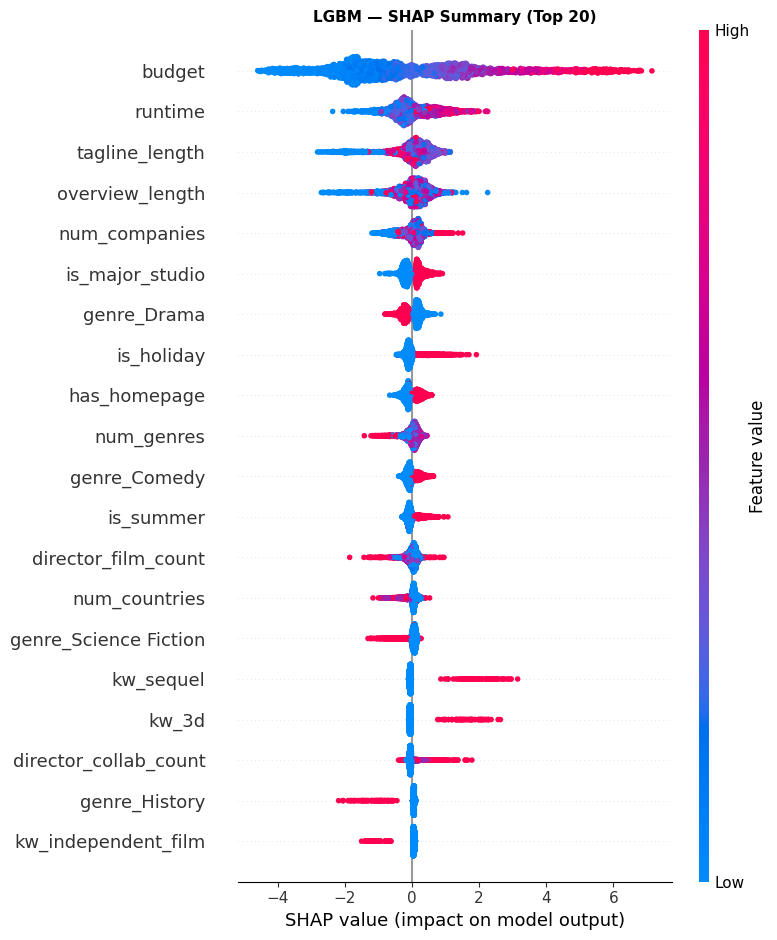

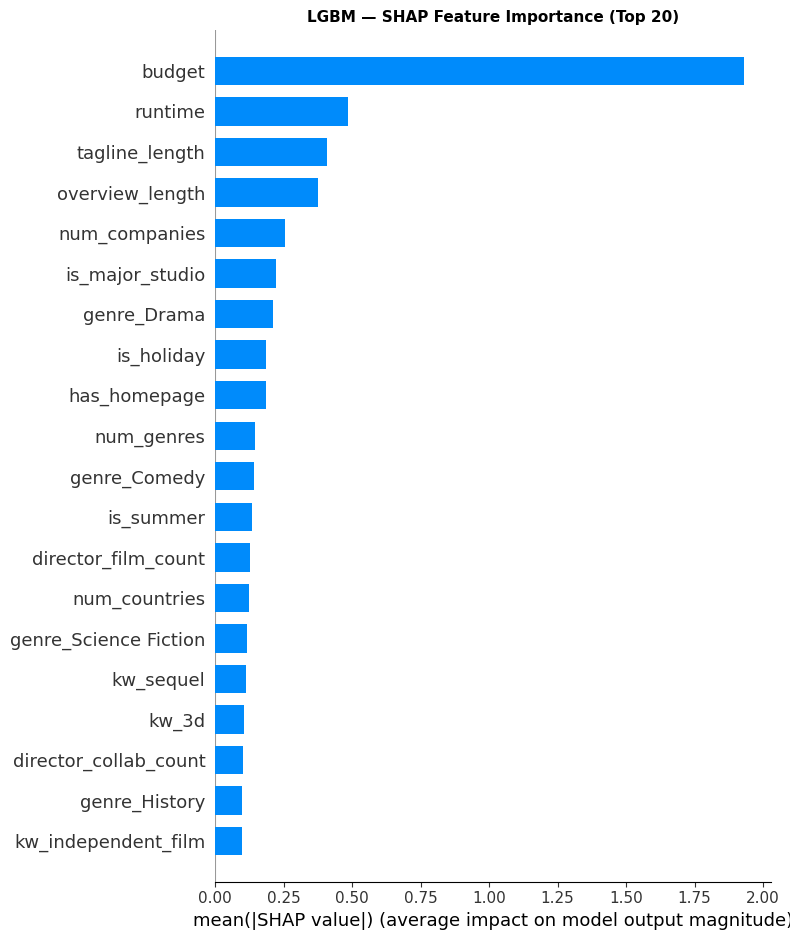

  ✓ baseline_lgbm_20260422_0015                        train=1.000  val=0.768  gap=+0.232
🏃 View run baseline_lgbm_20260422_0015 at: http://localhost:5000/#/experiments/1/runs/fa3ad0dc7e73441a9e81c79ad5d632fc
🧪 View experiment at: http://localhost:5000/#/experiments/1


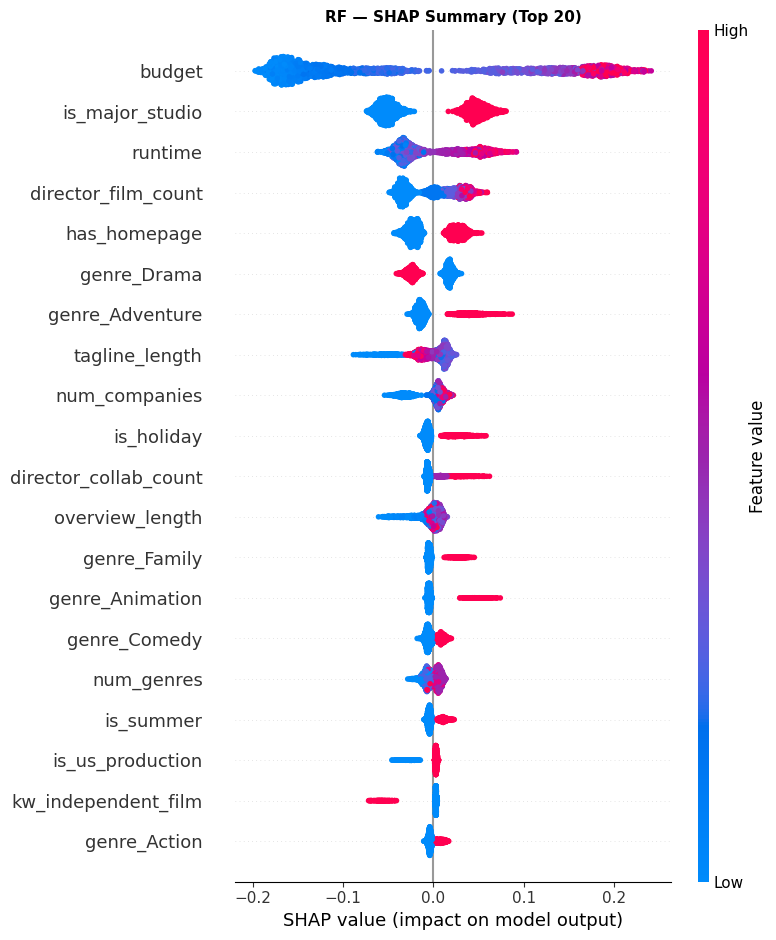

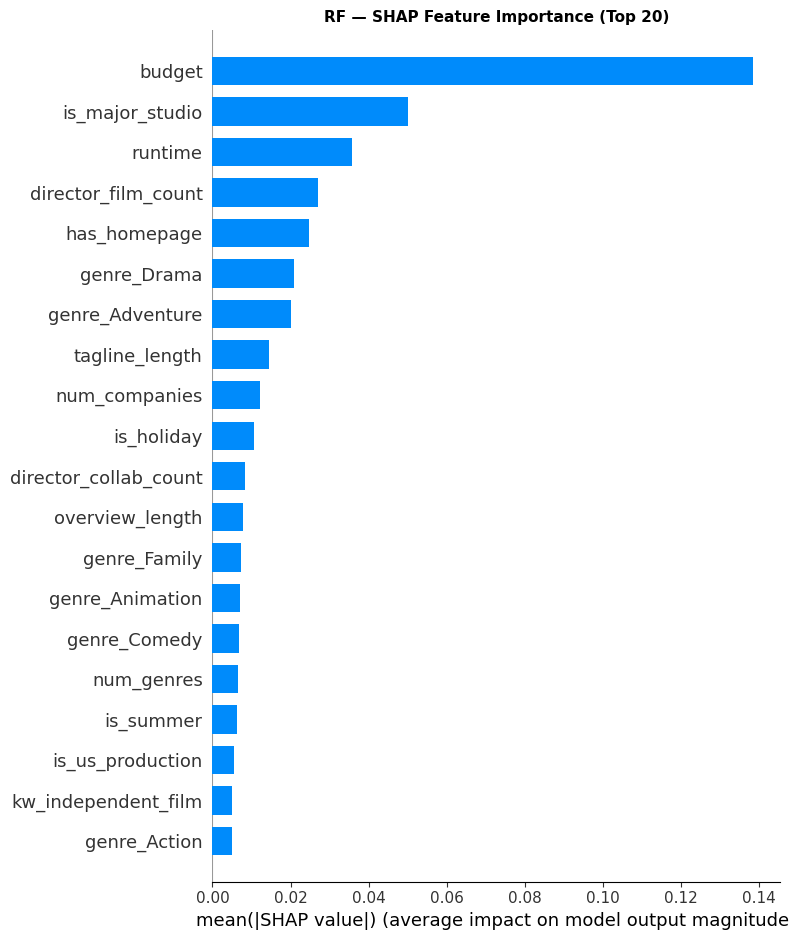

  ✓ baseline_rf_20260422_0015                          train=0.869  val=0.781  gap=+0.087
🏃 View run baseline_rf_20260422_0015 at: http://localhost:5000/#/experiments/1/runs/a6d8e416876c400abdbb657647f1b582
🧪 View experiment at: http://localhost:5000/#/experiments/1


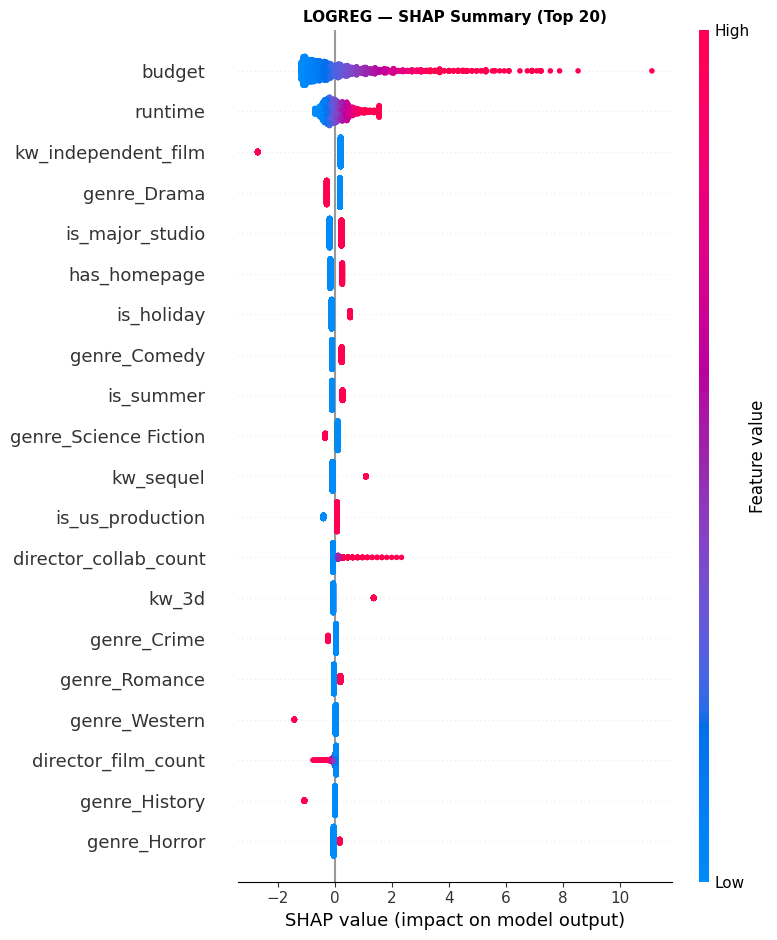

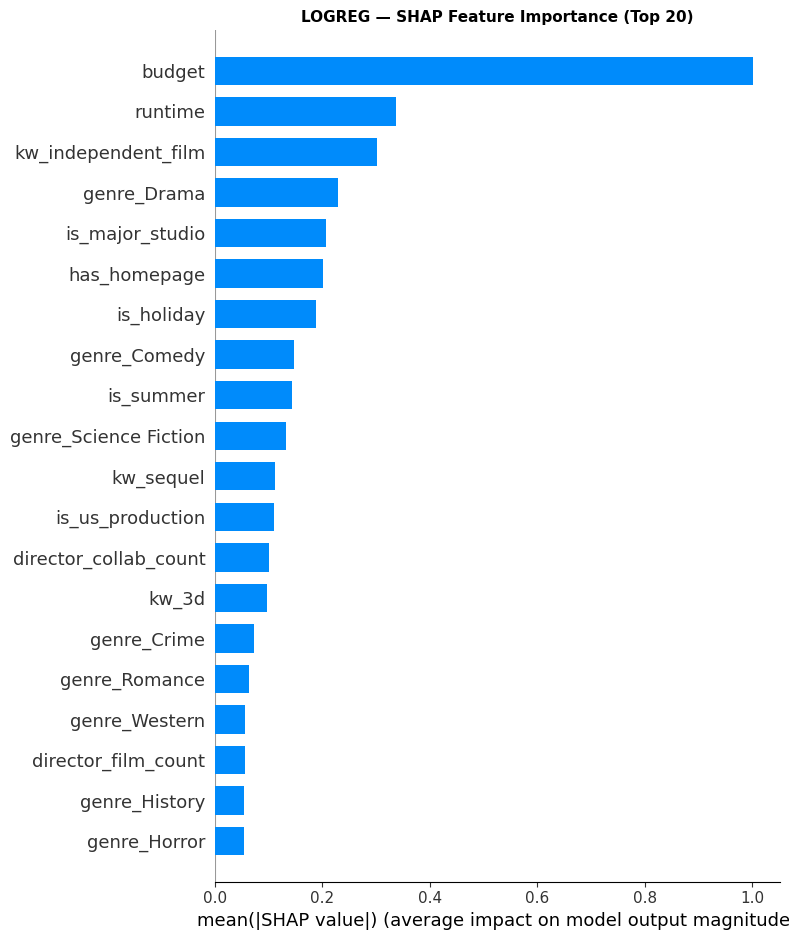

  ✓ baseline_logreg_20260422_0016                      train=0.805  val=0.785  gap=+0.019
🏃 View run baseline_logreg_20260422_0016 at: http://localhost:5000/#/experiments/1/runs/176e736fa6374ba4a4500f72fd971151
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260422_0015 at: http://localhost:5000/#/experiments/1/runs/7888c89dee5240b98240c980e490be5d
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tamamlandı


In [5]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,PRECISION,RECALL,AVG_PREC
Model,,,,,
lgbm,0.841,0.665,0.720,0.618,0.768
rf,0.853,0.701,0.671,0.734,0.781
logreg,0.851,0.700,0.680,0.721,0.785



🏆 En iyi model: logreg  (avg_prec=0.785)
🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/6585bfdf3f6341649286c800cdcea4af
🧪 View experiment at: http://localhost:5000/#/experiments/1


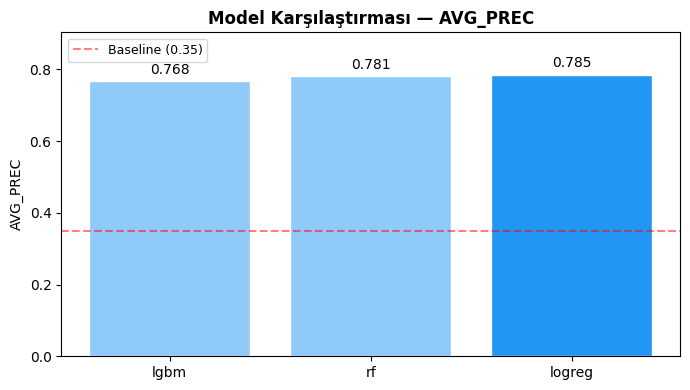


=== Overfitting / Underfitting Analizi ===


,Train AVG_PREC,Val AVG_PREC,Gap (Train−Val)
Model,,,
lgbm,1.000,0.768,0.232
rf,0.869,0.781,0.087
logreg,0.805,0.785,0.019


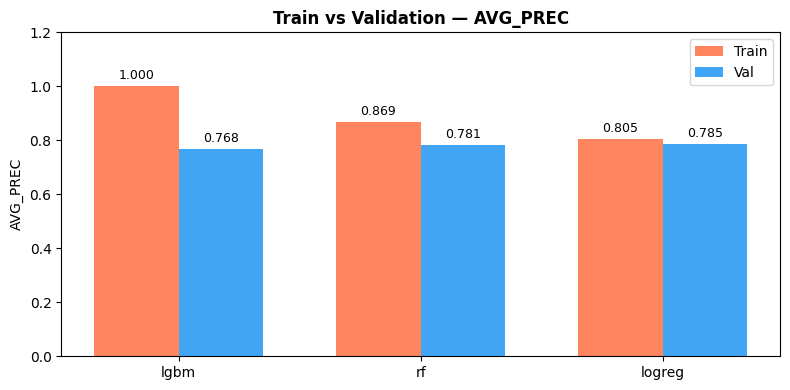

  ⚠️  lgbm: ciddi overfit (gap=0.232 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg'] — en iyi: logreg


In [6]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning (Tüm Modeller)

In [7]:
from src.automl import tune_all_models

best_model, best, tuned_models, ensemble_candidates = tune_all_models(
    results           = results,
    X                 = X_train,
    y                 = y_train,
    task_type         = TASK_TYPE,
    n_trials          = N_TRIALS,
    max_gap           = 0.10,
    X_val             = X_test,
    y_val             = y_test,
    jaccard_threshold = 0.60,
    feature_version   = FEATURE_VERSION,
)

if ensemble_candidates:
    print(f"\nEnsemble adayları: {list(ensemble_candidates.keys())}")


── Tuning: rf  (baseline=0.7815  min_improvement=0.0221) ──
Optuna başlıyor — model: rf  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7815
  Tuned     avg_prec: 0.7847
  İyileşme : +0.0032

  En iyi parametreler:
    n_estimators: 493
    max_depth: 8
    min_samples_leaf: 6
    max_features: log2
  Train-val gap: 0.0856  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_rf_20260422_0018 at: http://localhost:5000/#/experiments/1/runs/3e2d1bb619af44f399bd9513e7e4f026
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned rf
  — rf: iyileşme yetersiz (+0.0032 < 0.0221) — elendi

── Tuning: logreg  (baseline=0.7854  min_improvement=0.0139) ──
Optuna başlıyor — model: logreg  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7854
  Tuned     avg_prec: 0.7858
  İyileşme : +0.0004

  En iyi parametreler:
    C: 0.04532229216367551
  Train-val gap: 0.0183  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_logreg_20260422_0018 at: http://localhost:5000/#/experiments/1/runs/0591203ad82a4bc8820b0ee77e4464de
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned logreg
  — logreg: iyileşme yetersiz (+0.0004 < 0.0139) — elendi

⚠️  Recovery tuning: ['lgbm']  (eşik=0.2)

── Recovery Tuning: lgbm ──
Optuna başlıyor — model: lgbm  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7677
  Tuned     avg_prec: 0.7812
  İyileşme : +0.0135

  En iyi parametreler:
    n_estimators: 233
    learning_rate: 0.013229529356288778
    num_leaves: 56
    min_child_samples: 58
    reg_alpha: 0.0002912336700183757
    reg_lambda: 1.707769514441961
    subsample: 0.683470709247134
    colsample_bytree: 0.5096394582307014
  Train-val gap: 0.0800  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_lgbm_20260422_0019 at: http://localhost:5000/#/experiments/1/runs/b5d4086080de4518aeb51c5bb035389e
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned lgbm
  — lgbm: recovery tamamlandı (0.7812 ≤ 0.7858) — best model değişmedi

✓ tune_all_models tamamlandı — best: logreg  (avg_prec=0.7858)

── Ensemble Aday Analizi (Jaccard eşik=0.6) ──
  logreg ↔ rf: Jaccard=0.69 → atlandı (>0.6)
  logreg ↔ lgbm: Jaccard=0.70 → atlandı (>0.6)
  Yeterli çeşitlilik yok — ensemble önerilmiyo

## 5 — Test Değerlendirmesi

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       421
           1       0.65      0.72      0.68       225

    accuracy                           0.77       646
   macro avg       0.75      0.76      0.75       646
weighted avg       0.78      0.77      0.77       646


=== Test Metrikleri ===
  PR-AUC      : 0.7827
  ROC-AUC     : 0.8556
  F1          : 0.6837
  Precision   : 0.6545
  Recall      : 0.7156

=== LOGREG — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.785,0.783,-0.002
ROC-AUC,0.851,0.856,0.005
F1,0.700,0.684,-0.016
Precision,0.680,0.654,-0.026
Recall,0.721,0.716,-0.005


🏃 View run test_eval_logreg_20260422_0019 at: http://localhost:5000/#/experiments/1/runs/b8ddd13b790a44cb938f76f026d01d47
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


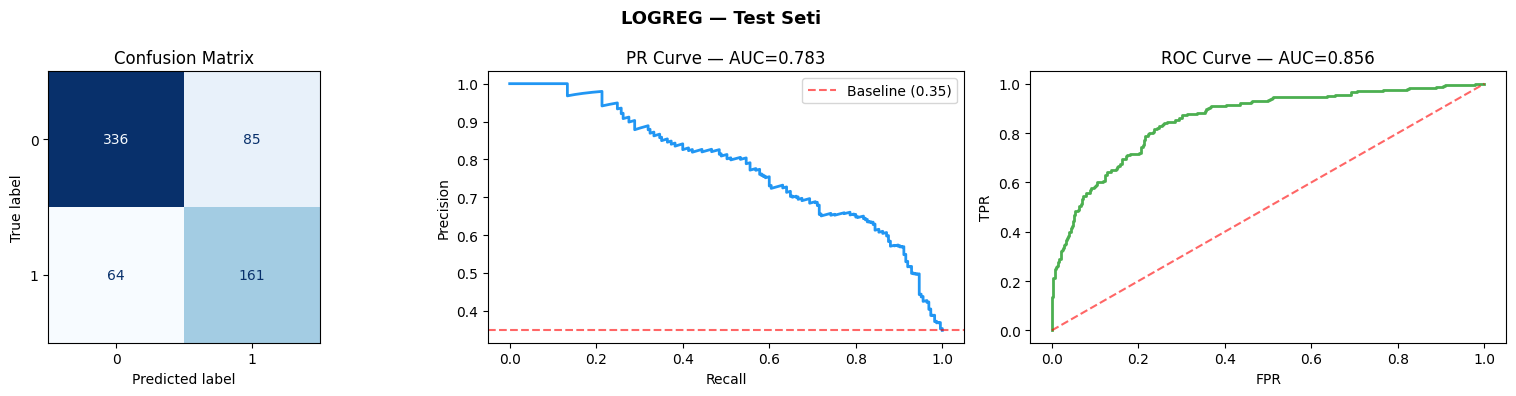

In [8]:
test_metrics = evaluate_test(
    best_model, X_test, y_test, TASK_TYPE, best,
    cv_metrics      = results[best]['val'],
    experiment_name = EXPERIMENT_NAME,
    feature_version = FEATURE_VERSION,
    features        = FEATURES,
)


## 6 — Rapor

In [9]:
from IPython.display import Markdown, display

report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

display(Markdown(report))

✓ Rapor oluşturuldu → experiment_report_20260422_001908.md
✓ MLflow'a kaydedildi → docs/experiment_report_20260422_001908.md
🏃 View run report_20260422_0019 at: http://localhost:5000/#/experiments/1/runs/66f1dd26ed2744588fddaea96c301cb2
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Experiment Raporu — tmdb_model

**Oluşturulma:** 2026-04-22 00:19  
**Task:** binary  
**Ana Metrik:** avg_prec  
**Dataset:** data/tmdb_model.csv  
**Toplam Film:** 3,226  |  **Hit Oranı:** %34.8  
**Özellik Sayısı:** 41  

---

## Baseline Sonuçları

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|----|-----------|----|
| logreg | 0.785 | 0.851 | 0.700 | 0.680 | 0.721 |
| rf | 0.781 | 0.853 | 0.701 | 0.671 | 0.734 |
| lgbm | 0.768 | 0.841 | 0.665 | 0.720 | 0.618 |

---

## Tuning

- **lgbm** — Baseline avg_prec: 0.768 → Tuned: 0.781 (İyileşme: 0.013)
- **logreg** — Baseline avg_prec: 0.785 → Tuned: 0.786 (İyileşme: 0.000)
- **rf** — Baseline avg_prec: 0.781 → Tuned: 0.785 (İyileşme: 0.003)

---

## Test Seti Sonuçları

| Metrik | Değer |
|--------|-------|
| PRECISION | 0.654 |
| ROC_AUC | 0.856 |
| PR_AUC | 0.783 |
| F1 | 0.684 |
| RECALL | 0.716 |

## 7 — Hibrit Modeller

Baseline modellerin (LGBM, RF, LogReg) güçlü yönlerini birleştirmek için üç strateji deneniyor.

| Yöntem | Fikir | Artısı | Eksi |
|--------|-------|--------|------|
| **Voting** | Olasılıkların ağırlıklı ortalaması | Basit, hızlı, yorumlanabilir | Modeller aynı hatayı paylaşabilir |
| **Stacking** | CV ile out-of-fold meta-özellik → meta-model | En güçlü kombinasyon | Yavaş, dikkatli CV gerektirir |
| **Blending** | Holdout meta-özellik → meta-model (CV yok) | Hızlı, leakage riski düşük | Daha az veri verimli |

In [10]:
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier, StackingClassifier

ir = (y_train == 0).sum() / (y_train == 1).sum()

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    )

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

print(f'✓ Base model factory hazır  |  imbalance_ratio: {ir:.3f}')

✓ Base model factory hazır  |  imbalance_ratio: 1.870


### 7a — Voting Ensemble

`VotingClassifier(voting='soft')` her modelin olasılık tahminlerini ağırlıklı ortalamayla birleştirir.
LGBM baseline'da en güçlü performansı gösterdiği için `weights=[2, 1, 1]` kullanıyoruz.

Voting top-2 : ['logreg', 'rf']
Weights      : ['0.7854', '0.7815']
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       421
           1       0.68      0.76      0.72       225

    accuracy                           0.79       646
   macro avg       0.77      0.78      0.78       646
weighted avg       0.80      0.79      0.79       646


=== Test Metrikleri ===
  PR-AUC      : 0.7984
  ROC-AUC     : 0.8629
  F1          : 0.7170
  Precision   : 0.6786
  Recall      : 0.7600

=== VOTING_ENSEMBLE — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.785,0.798,0.013
ROC-AUC,0.851,0.863,0.012
F1,0.700,0.717,0.017
Precision,0.680,0.679,-0.001
Recall,0.721,0.760,0.039


🏃 View run test_eval_voting_ensemble_20260422_0019 at: http://localhost:5000/#/experiments/1/runs/e16477bfff684aa38640ef8af25ad14e
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


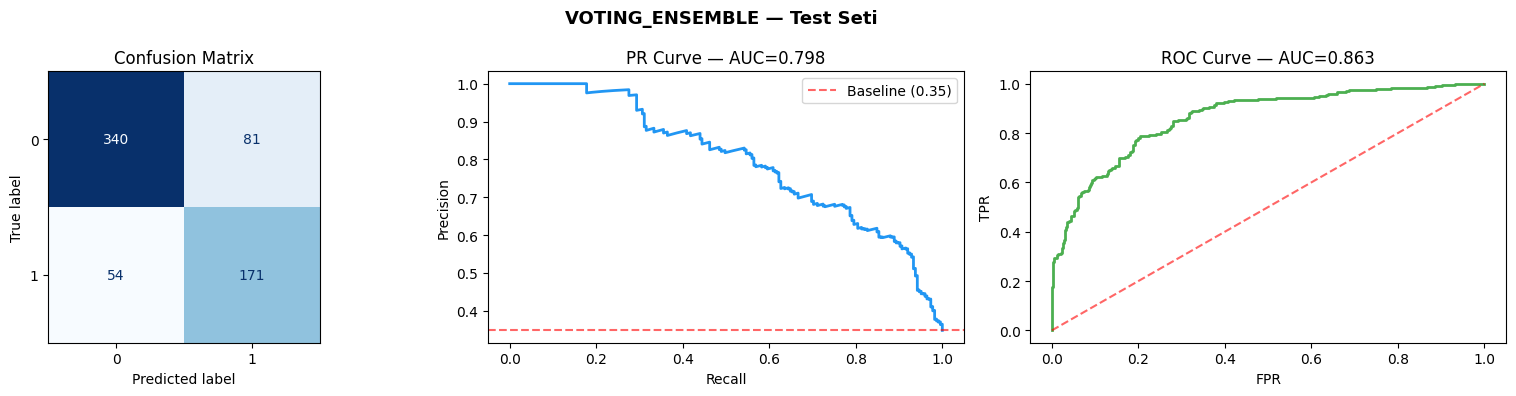

Voting top-3 : ['logreg', 'rf', 'lgbm']
Weights      : ['0.7854', '0.7815', '0.7677']
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       421
           1       0.67      0.75      0.71       225

    accuracy                           0.79       646
   macro avg       0.77      0.78      0.77       646
weighted avg       0.79      0.79      0.79       646


=== Test Metrikleri ===
  PR-AUC      : 0.8050
  ROC-AUC     : 0.8658
  F1          : 0.7089
  Precision   : 0.6747
  Recall      : 0.7467

=== VOTING3_ENSEMBLE — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.785,0.805,0.020
ROC-AUC,0.851,0.866,0.015
F1,0.700,0.709,0.009
Precision,0.680,0.675,-0.005
Recall,0.721,0.747,0.026


🏃 View run test_eval_voting3_ensemble_20260422_0019 at: http://localhost:5000/#/experiments/1/runs/93d15c7036a2463f9530e28c098743cb
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


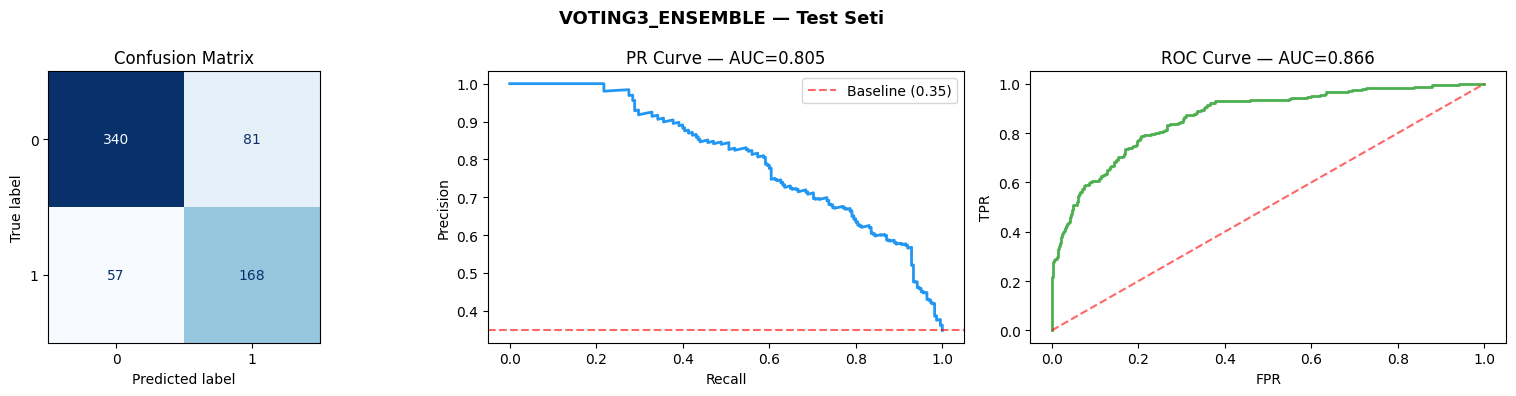

In [11]:
# Top-2 seçimi: val avg_prec sıralaması
ranked = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("avg_prec", 0),
    reverse=True,
)[:2]

scores  = {name: results[name]["val"]["avg_prec"] for name in ranked}
weights = [scores[name] for name in ranked]

print(f"Voting top-2 : {ranked}")
print(f"Weights      : {[f'{w:.4f}' for w in weights]}")

voting_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked],
    voting="soft",
    weights=weights,
    n_jobs=1,
)
voting_clf.fit(X_train, y_train)

voting_metrics = evaluate_test(
    voting_clf, X_test, y_test, TASK_TYPE, "voting_ensemble",
    cv_metrics=results[best]["val"],
    experiment_name=EXPERIMENT_NAME,
    feature_version=FEATURE_VERSION,
)

# Top-3: tüm tuned modeller
ranked3  = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("avg_prec", 0),
    reverse=True,
)
scores3  = {name: results[name]["val"]["avg_prec"] for name in ranked3}
weights3 = [scores3[name] for name in ranked3]

print(f"Voting top-3 : {ranked3}")
print(f"Weights      : {[f'{w:.4f}' for w in weights3]}")

voting3_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked3],
    voting="soft",
    weights=weights3,
    n_jobs=1,
)
voting3_clf.fit(X_train, y_train)

voting3_metrics = evaluate_test(
    voting3_clf, X_test, y_test, TASK_TYPE, "voting3_ensemble",
    cv_metrics=results[best]["val"],
    experiment_name=EXPERIMENT_NAME,
    feature_version=FEATURE_VERSION,
)

### 7b — Stacking

`StackingClassifier` her base modeli 5-fold CV ile eğitip out-of-fold tahminlerini
meta-özellik olarak kullanır. Meta-model (LogisticRegression) bu özelliklerden öğrenir.

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       421
           1       0.71      0.68      0.69       225

    accuracy                           0.79       646
   macro avg       0.77      0.77      0.77       646
weighted avg       0.79      0.79      0.79       646


=== Test Metrikleri ===
  PR-AUC      : 0.8025
  ROC-AUC     : 0.8649
  F1          : 0.6941
  Precision   : 0.7136
  Recall      : 0.6756

=== STACKING — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.785,0.803,0.018
ROC-AUC,0.851,0.865,0.014
F1,0.700,0.694,-0.006
Precision,0.680,0.714,0.034
Recall,0.721,0.676,-0.045


🏃 View run test_eval_stacking_20260422_0019 at: http://localhost:5000/#/experiments/1/runs/2c3af2b9d8a54bc488fce4c949268712
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


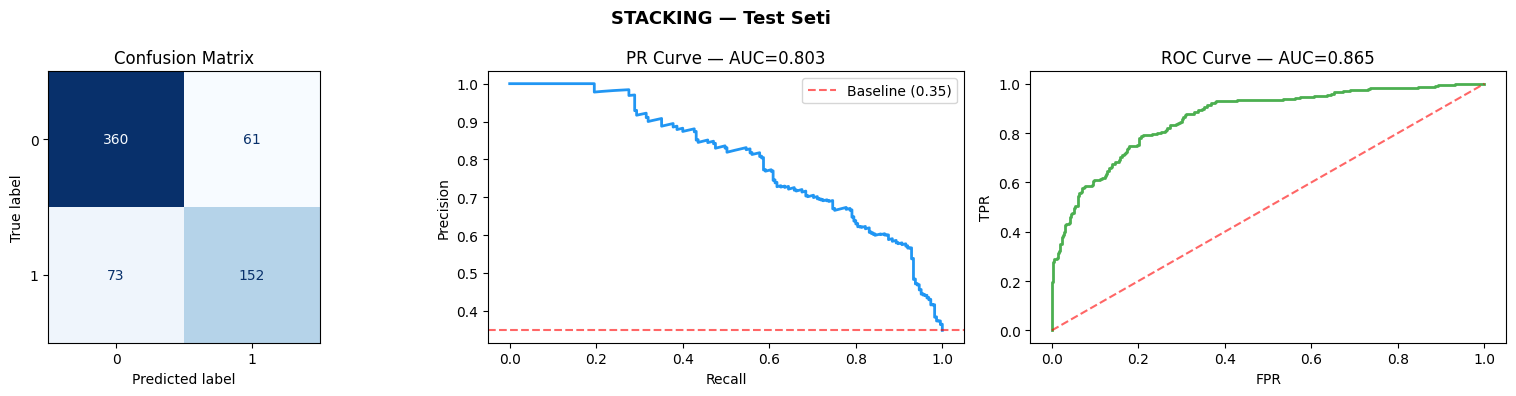

In [12]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lgbm',   clone(tuned_models['lgbm'])),
        ('rf',     clone(tuned_models['rf'])),
        ('logreg', clone(tuned_models['logreg'])),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)

stacking_metrics = evaluate_test(
    stacking_clf, X_test, y_test, TASK_TYPE, 'stacking',
    cv_metrics=results[best]['val'],
    experiment_name=EXPERIMENT_NAME,
    feature_version=FEATURE_VERSION,
)

### 7c — Blending

Train setinin %20'si **holdout** olarak ayrılır. Base modeller kalan %80 üzerinde eğitilir;
holdout tahminleri meta-model için girdi oluşturur. Stacking'e kıyasla daha hızlı ama
daha az veri verimlidir.

In [13]:
class BlendingEnsemble:
    """
    Blending stratejisi:
      1. X_train → blend_train (%80) + holdout (%20) olarak bölünür.
      2. Base modeller yalnızca blend_train üzerinde eğitilir.
      3. Holdout tahminleri (predict_proba) meta-özellik matrisini oluşturur.
      4. Meta-model bu matris üzerinde eğitilir.
      5. Test tahminleri: base modeller test setini tahmin eder → meta-model birleştirir.

    Stacking'den farkı: CV yoktur; bilgi sızıntısını önlemek için ayrı bir holdout kullanılır.
    """

    def __init__(self, base_models: list, meta_model, blend_ratio: float = 0.2,
                 random_state: int = 42):
        self.base_models  = base_models   # [(isim, estimator), ...]
        self.meta_model   = meta_model
        self.blend_ratio  = blend_ratio
        self.random_state = random_state

    def fit(self, X, y):
        from sklearn.model_selection import train_test_split
        X_bt, X_hold, y_bt, y_hold = train_test_split(
            X, y,
            test_size=self.blend_ratio,
            stratify=y,
            random_state=self.random_state,
        )
        for _, m in self.base_models:
            m.fit(X_bt, y_bt)

        meta_train = np.column_stack([
            m.predict_proba(X_hold)[:, 1] for _, m in self.base_models
        ])
        self.meta_model.fit(meta_train, y_hold)
        return self

    def predict_proba(self, X):
        meta = np.column_stack([
            m.predict_proba(X)[:, 1] for _, m in self.base_models
        ])
        prob1 = self.meta_model.predict_proba(meta)[:, 1]
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('✓ BlendingEnsemble sınıfı tanımlandı')

✓ BlendingEnsemble sınıfı tanımlandı


              precision    recall  f1-score   support

           0       0.83      0.86      0.84       421
           1       0.72      0.67      0.69       225

    accuracy                           0.79       646
   macro avg       0.77      0.76      0.77       646
weighted avg       0.79      0.79      0.79       646


=== Test Metrikleri ===
  PR-AUC      : 0.8046
  ROC-AUC     : 0.8655
  F1          : 0.6927
  Precision   : 0.7156
  Recall      : 0.6711

=== BLENDING — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.785,0.805,0.020
ROC-AUC,0.851,0.866,0.015
F1,0.700,0.693,-0.007
Precision,0.680,0.716,0.036
Recall,0.721,0.671,-0.050


🏃 View run test_eval_blending_20260422_0019 at: http://localhost:5000/#/experiments/1/runs/230c9ea70c11476786a2c9d91efac871
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


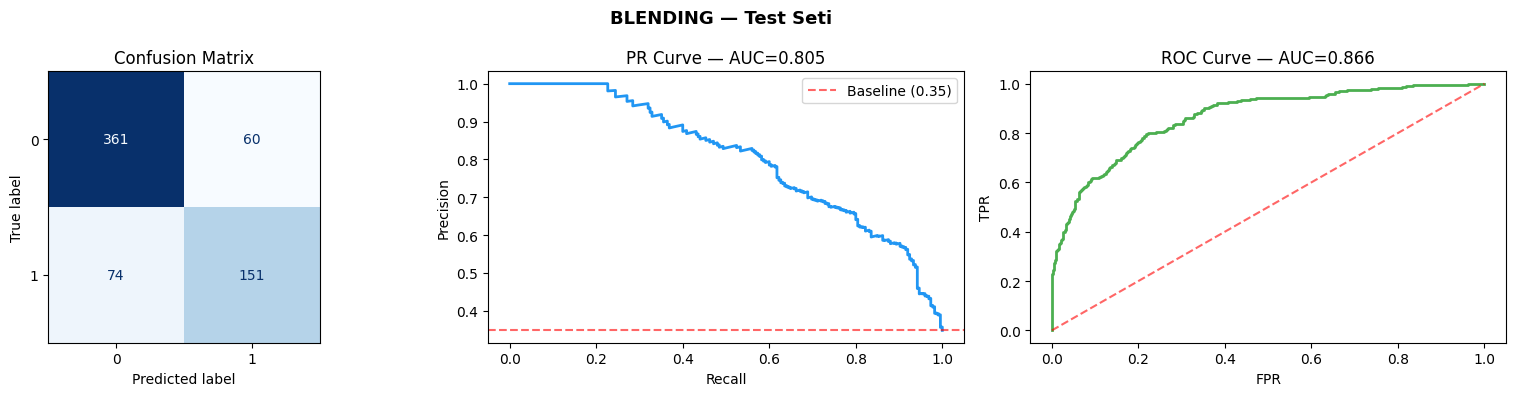

In [14]:
blending_clf = BlendingEnsemble(
    base_models=[(name, clone(tuned_models[name])) for name in tuned_models],
    meta_model=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    blend_ratio=0.2,
    random_state=RANDOM_STATE,
)
blending_clf.fit(X_train, y_train)

blending_metrics = evaluate_test(
    blending_clf, X_test, y_test, TASK_TYPE, 'blending',
    cv_metrics=results[best]['val'],
    experiment_name=EXPERIMENT_NAME,
    feature_version=FEATURE_VERSION,
)

### Tüm Hibrit Modellerin Karşılaştırması

=== Hibrit Model Karşılaştırması ===


,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,
best_single (logreg),0.7827,0.8556,0.6837,0.6545,0.7156
voting_top2,0.7984,0.8629,0.7170,0.6786,0.7600
voting_top3,0.8050,0.8658,0.7089,0.6747,0.7467
stacking,0.8025,0.8649,0.6941,0.7136,0.6756
blending,0.8046,0.8655,0.6927,0.7156,0.6711


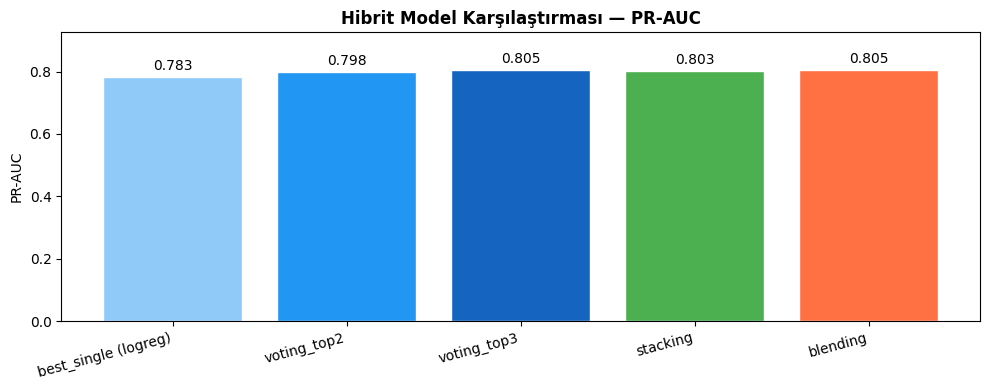

In [15]:
metric_col = "PR-AUC"
hybrid_results = {
    f"best_single ({best})": test_metrics,
    "voting_top2":           voting_metrics,
    "voting_top3":           voting3_metrics,
    "stacking":              stacking_metrics,
    "blending":              blending_metrics,
}

rows = []
for name, m in hybrid_results.items():
    rows.append({"Model": name, **{k: round(v, 4) for k, v in m.items()}})
comparison_df = pd.DataFrame(rows).set_index("Model")
print("=== Hibrit Model Karşılaştırması ===")
display(comparison_df)

vals   = [m.get(metric_col, 0) for m in hybrid_results.values()]
labels = list(hybrid_results.keys())
colors = ["#90CAF9", "#2196F3", "#1565C0", "#4CAF50", "#FF7043"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_title(f"Hibrit Model Karşılaştırması — {metric_col}", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_ylabel(metric_col)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### Final Model Seçimi

In [16]:
all_candidates = {
    f"best_single ({best})": (best_model,    test_metrics),
    "voting_top2":           (voting_clf,    voting_metrics),
    "voting_top3":           (voting3_clf,   voting3_metrics),
    "stacking":              (stacking_clf,  stacking_metrics),
    "blending":              (blending_clf,  blending_metrics),
}

main_metric_key = "PR-AUC"
final_name  = max(all_candidates, key=lambda n: all_candidates[n][1].get(main_metric_key, 0))
final_model = all_candidates[final_name][0]
final_metrics = all_candidates[final_name][1]

print("=== Final Model ===")
print(f"  Model     : {final_name}")
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")


=== Final Model ===
  Model     : voting_top3
  PR-AUC      : 0.8050
  ROC-AUC     : 0.8658
  F1          : 0.7089
  Precision   : 0.6747
  Recall      : 0.7467


In [17]:
import json, tempfile
from collections import defaultdict
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp    = client.get_experiment_by_name(EXPERIMENT_NAME)

if exp:
    eid = exp.experiment_id

    # ── Champion Tracking ────────────────────────────────────────────
    # Skor karşılaştırması: sadece temiz era (feature_version eşleşen) run'lar
    clean_test_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string=(
            f"tags.stage = 'test' "
            f"AND tags.feature_version = '{FEATURE_VERSION}'"
        ),
        order_by=["metrics.test_pr_auc DESC"],
    )

    curr_score = final_metrics.get('PR-AUC', 0)

    if clean_test_runs:
        champion   = clean_test_runs[0]
        hist_score = champion.data.metrics.get('test_pr_auc', 0)
        delta      = curr_score - hist_score
        symbol     = "Yeni şampiyon!" if delta > 0 else "Geçilemedi"
        print("=== Champion Tracking ===")
        print(f"  Geçmiş en iyi  : {hist_score:.4f}  ({champion.info.run_name})")
        print(f"  Mevcut         : {curr_score:.4f}  ({final_name})")
        print(f"  Fark           : {delta:+.4f}  — {symbol}")

        artifact_names = {a.path for a in client.list_artifacts(champion.info.run_id)}
        if "features.json" in artifact_names:
            try:
                with tempfile.TemporaryDirectory() as tmp:
                    path = client.download_artifacts(champion.info.run_id, "features.json", tmp)
                    with open(path) as f:
                        hist_features = set(json.load(f)["features"])
                curr_features = set(FEATURES)
                added   = sorted(curr_features - hist_features)
                removed = sorted(hist_features - curr_features)
                print(f"\n=== Feature Karşılaştırması ===")
                print(f"  Geçmiş : {len(hist_features)} feature")
                print(f"  Mevcut : {len(curr_features)} feature")
                if added:
                    print(f"  Eklenen  (+{len(added)}): {', '.join(added)}")
                if removed:
                    print(f"  Çıkarılan (-{len(removed)}): {', '.join(removed)}")
                if not added and not removed:
                    print("  Feature seti değişmedi.")
            except Exception:
                pass
        else:
            print("\n  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)")
    else:
        champion = None
        print("=== Champion Tracking ===")
        print(f"  İlk run — referans skor: {curr_score:.4f}  ({final_name})")
        print(f"  Feature sayısı: {len(FEATURES)}")

    # ── Genel MLflow Temizliği ────────────────────────────────────────

    # 1. Tüm test run'ları çek (feature_version filtresi YOK — tüm era dahil)
    all_test_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.stage = 'test'",
        order_by=["metrics.test_pr_auc DESC"],
    )
    champion_id = champion.info.run_id if champion else None
    stale_test  = [r for r in all_test_runs if r.info.run_id != champion_id]
    for r in stale_test:
        client.delete_run(r.info.run_id)
    if stale_test:
        print(f"\n✓ {len(stale_test)} eski test run'ı silindi — şampiyon korundu")

    # 2. Summary, report, session — türetilmiş bilgi, tümünü sil
    for run_type in ("summary", "report", "session"):
        to_del = list(client.search_runs(
            experiment_ids=[eid],
            filter_string=f"tags.type = '{run_type}'",
        ))
        for r in to_del:
            client.delete_run(r.info.run_id)
        if to_del:
            print(f"✓ {len(to_del)} {run_type} run'ı silindi")

    # 3. Tuning — model başına en yüksek skoru koru (tüm era dahil)
    tuning_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'tuning'",
        order_by=["metrics.tuned_avg_prec DESC"],
    )
    by_model = defaultdict(list)
    for r in tuning_runs:
        by_model[r.data.tags.get("model_type", "unknown")].append(r)

    tuning_deleted = 0
    for runs in by_model.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            tuning_deleted += 1
    if tuning_deleted:
        print(f"✓ {tuning_deleted} eski tuning run'ı silindi — model başına 1 korundu")

    # 4. Baseline — model başına en son run'ı koru (tüm era dahil)
    baseline_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'baseline'",
        order_by=["start_time DESC"],
    )
    by_model_bl = defaultdict(list)
    for r in baseline_runs:
        by_model_bl[r.data.tags.get("model_type", "unknown")].append(r)

    baseline_deleted = 0
    for runs in by_model_bl.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            baseline_deleted += 1
    if baseline_deleted:
        print(f"✓ {baseline_deleted} eski baseline run'ı silindi — model başına 1 korundu")

    # 5. Bilinmeyen tip run'lar (feature_selection vb.) — tümünü sil
    known_types  = {"test_evaluation", "tuning", "baseline", "summary", "report", "session"}
    all_runs     = client.search_runs(experiment_ids=[eid])
    other_deleted = 0
    for r in all_runs:
        tags      = r.data.tags
        run_type  = tags.get("type", "")
        run_stage = tags.get("stage", "")
        is_known  = run_type in known_types or run_stage == "test"
        if not is_known and r.info.run_id != champion_id:
            client.delete_run(r.info.run_id)
            other_deleted += 1
    if other_deleted:
        print(f"✓ {other_deleted} diğer run silindi (feature_selection vb.)")

else:
    print(f"MLflow experiment '{EXPERIMENT_NAME}' bulunamadı.")

=== Champion Tracking ===
  Geçmiş en iyi  : 0.8126  (test_eval_stacking_20260421_1429)
  Mevcut         : 0.8050  (voting_top3)
  Fark           : -0.0076  — Geçilemedi

  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)

✓ 6 eski test run'ı silindi — şampiyon korundu
✓ 2 summary run'ı silindi
✓ 2 report run'ı silindi
✓ 2 session run'ı silindi
✓ 6 eski tuning run'ı silindi — model başına 1 korundu
✓ 6 eski baseline run'ı silindi — model başına 1 korundu
